# Exploratory Data Analysis - MIT-BIH Arrhythmia Database

In [1]:
import pandas as pd

from wfdb.io.annotation import ann_label_table

from ecg_waveform.config import (
    load_yaml,
    MITDB_DIR,
    get_mitdb_record_names,
    ensure_directories,
)

from ecg_waveform.data import WFDBLoader

from ecg_waveform.visualization import (
    set_style,
    plot_signal,
    plot_amplitude_distribution,
    plot_beat_overlays,
    plot_rr_tachogram,
    plot_rr_distribution,
    plot_poincare,
)

from _nb_exploratory_analysis import (
    summarize_record,
    summarize_signal,
    summarize_signal_quality,
    summarize_annotation,
    summarize_database,
    summarize_database_annotations,
)

ensure_directories()

set_style()

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [3]:
loader = WFDBLoader(MITDB_DIR, "atr")
record = loader[get_mitdb_record_names()[0]]
signal = record.get_signal(0)

R_PEAK_SYMBOLS = load_yaml("annotation_labels.yaml")["r_peaks"]

r_peaks = signal.annotation.filter(R_PEAK_SYMBOLS)

In [4]:
summarize_record(record)

,Property,Value
0,Record name,100
1,Number of leads,2
2,Leads,"MLII, V5"
3,Sample rate (Hz),360
4,Number of samples,650000
5,Duration (s),1805.556


In [5]:
summarize_signal(signal)

,Property,Value
0,Lead name,MLII
1,Sample rate (Hz),360
2,Number of samples,650000
3,Duration (s),1805.556
4,Min (mV),-2.715
5,Max (mV),1.435
6,Mean (mV),-0.306
7,Std (mV),0.193
8,Dynamic range,4.15
9,Outlier ratio (%),0.0


(<Figure size 3600x1200 with 1 Axes>,
 <Axes: title={'center': 'ECG Signal — MLII lead — 0.00-10.00 s'}, xlabel='Time (s)', ylabel='Amplitude (mV)'>)

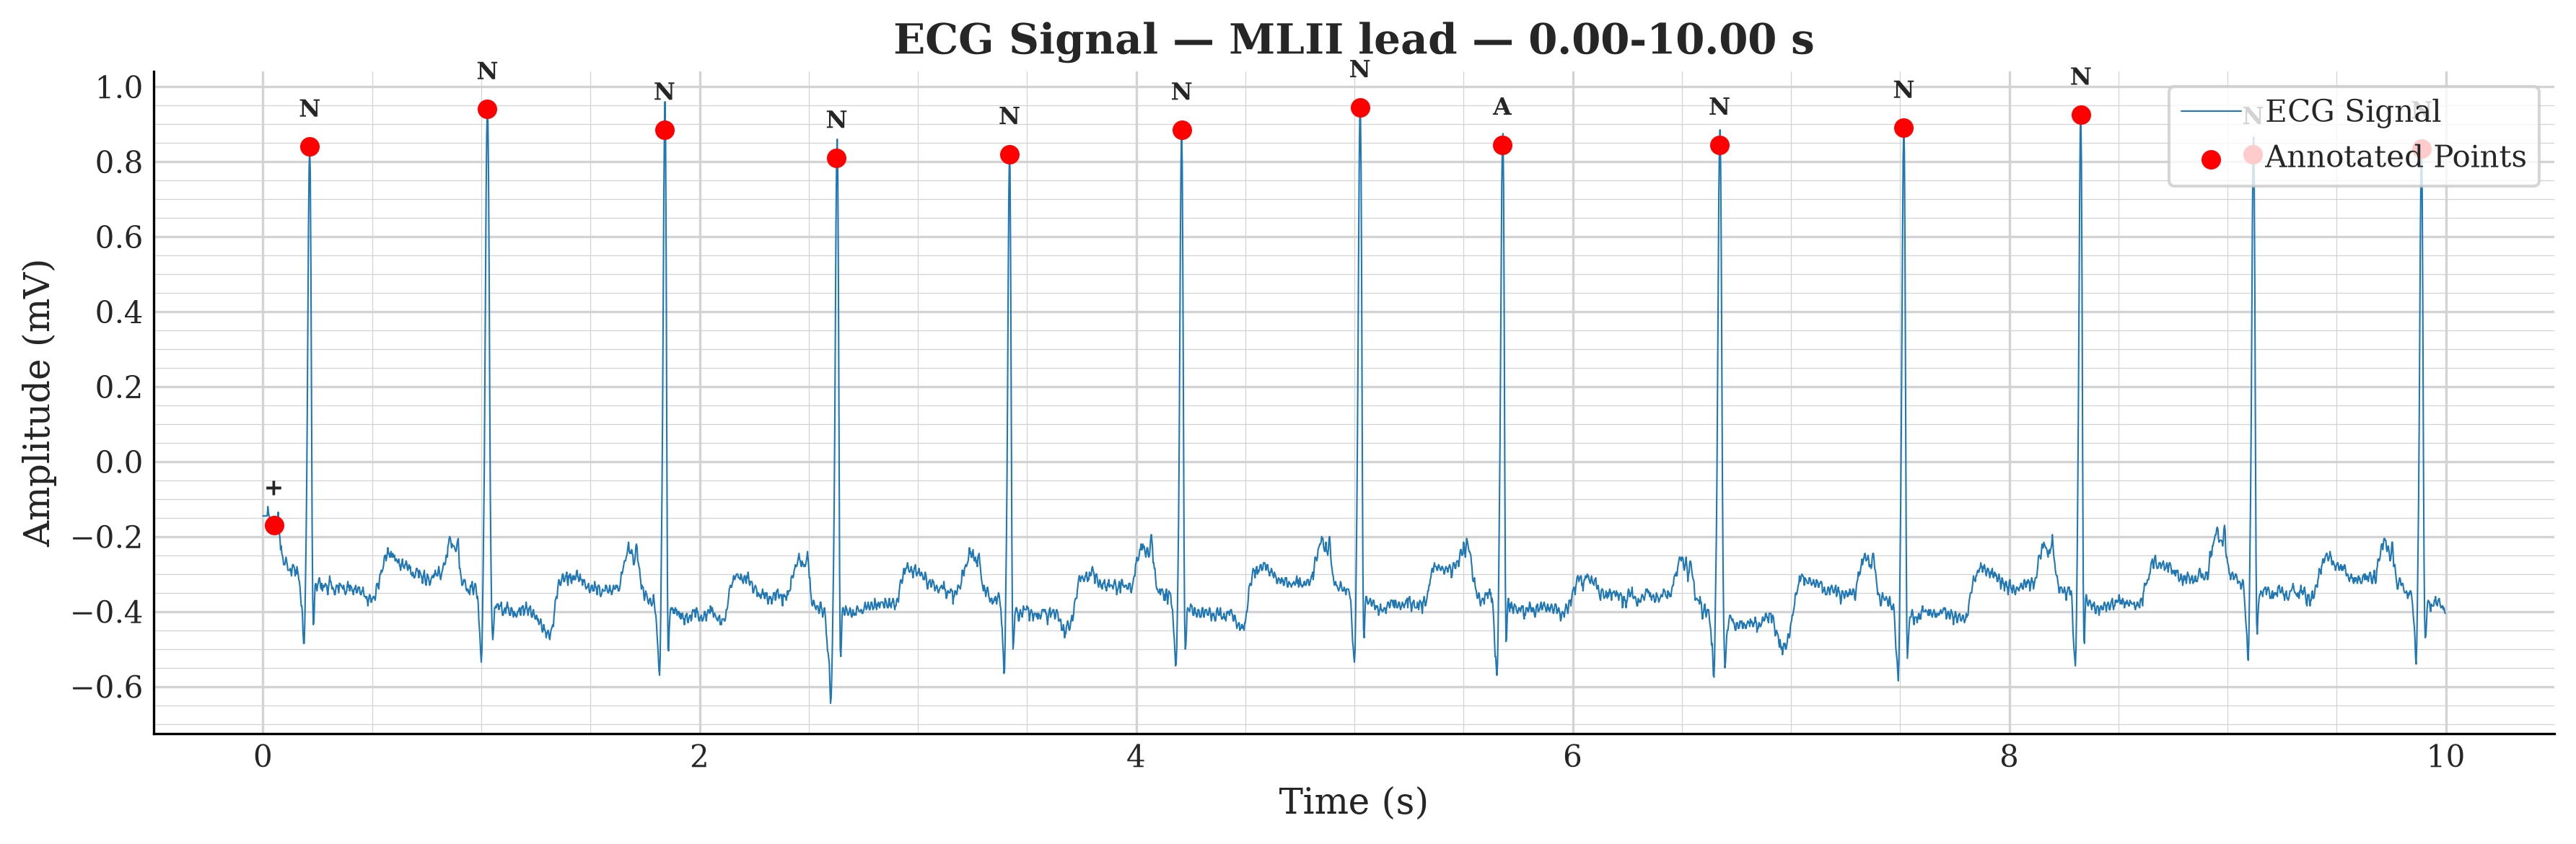

In [6]:
plot_signal(signal)

(<Figure size 3600x1200 with 1 Axes>,
 <Axes: title={'center': 'Amplitude distribution'}, xlabel='Amplitude (mV)', ylabel='Count'>)

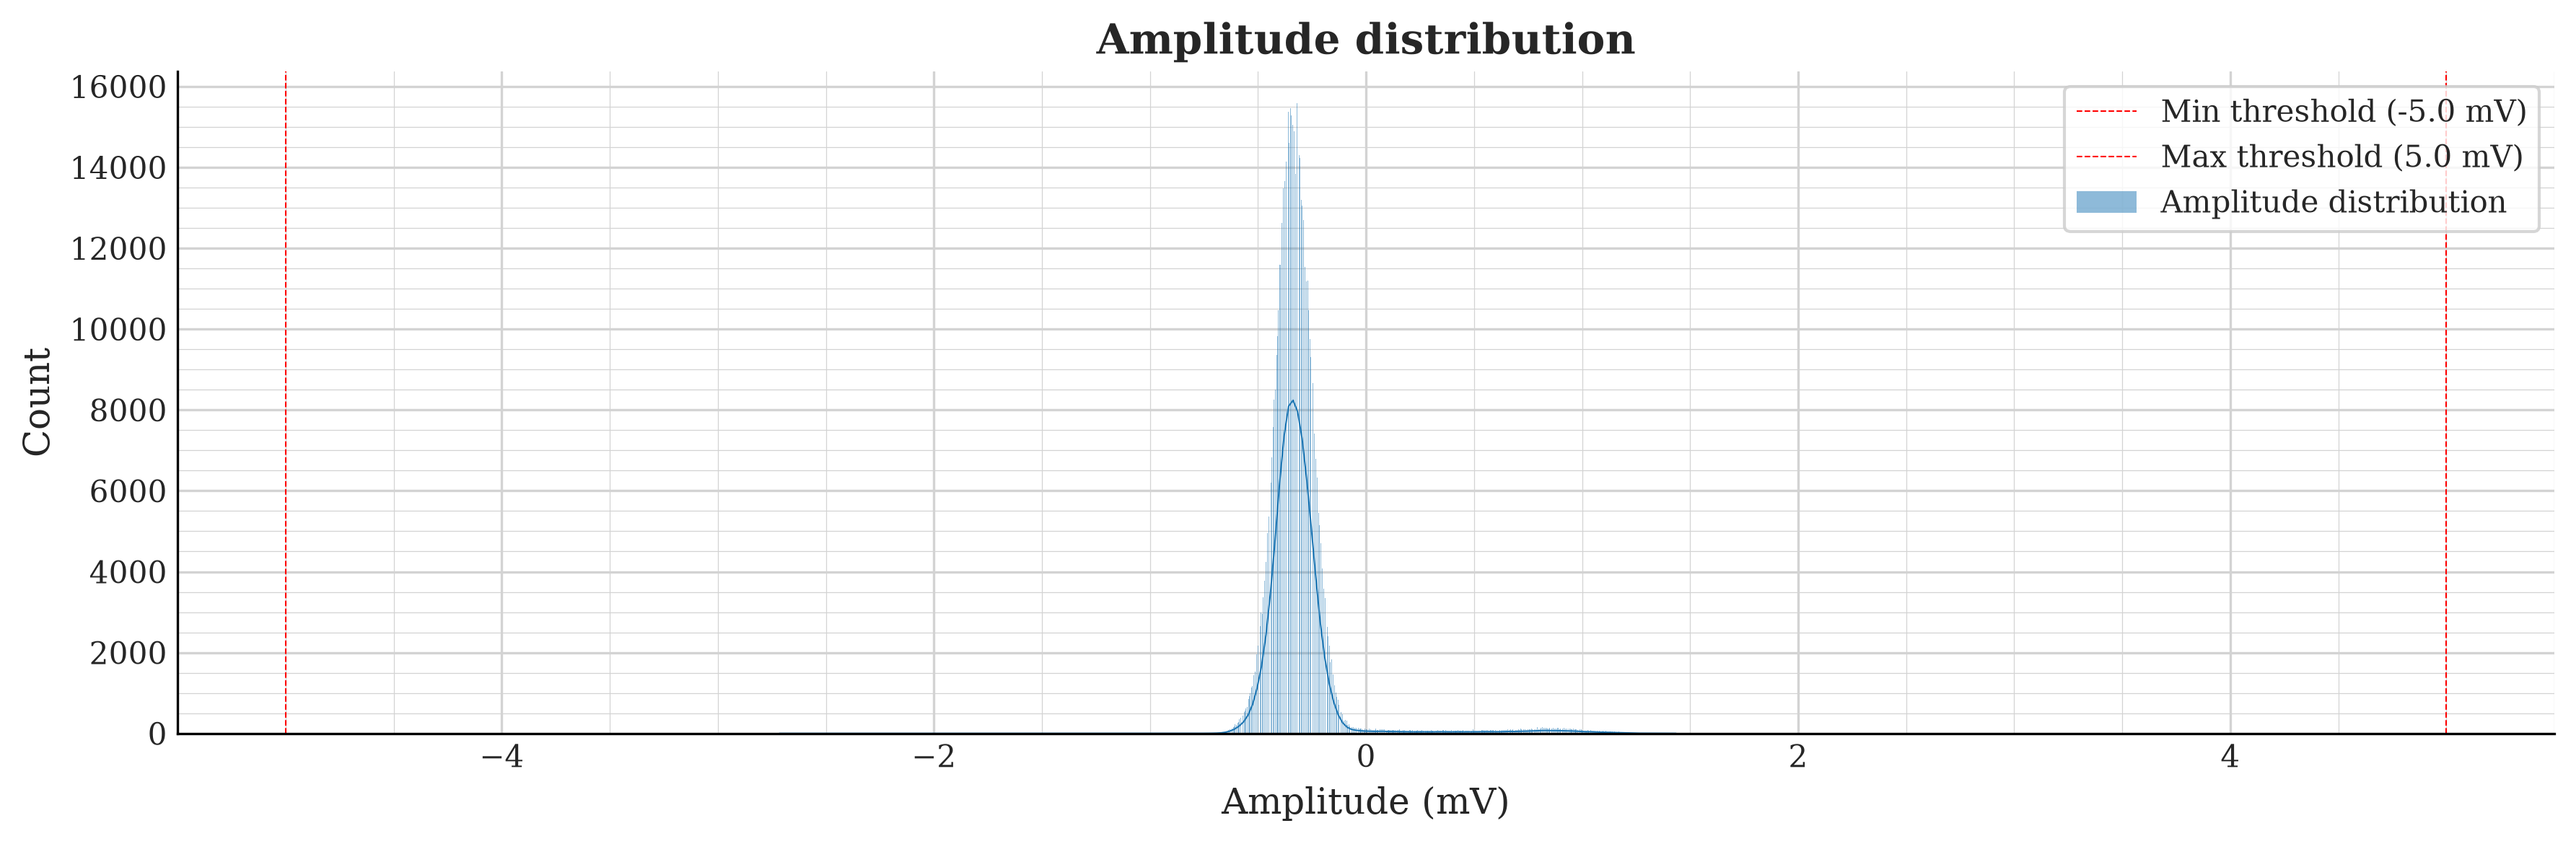

In [7]:
plot_amplitude_distribution(signal)

In [8]:
summarize_signal_quality(signal)

,Property,Value
0,Kurtosis SQI,25.413
1,QRS Power SQI,0.445
2,Powerline Noise Ratio (50.0 Hz),0.001
3,Powerline Noise Ratio (60.0 Hz),0.001
4,Baseline Wander Ratio,0.880
5,Flatline Ratio,0.000


(<Figure size 3600x1200 with 1 Axes>,
 <Axes: title={'center': 'ECG Beat Overlay (2272 beats)'}, xlabel='Time (ms)', ylabel='Amplitude'>)

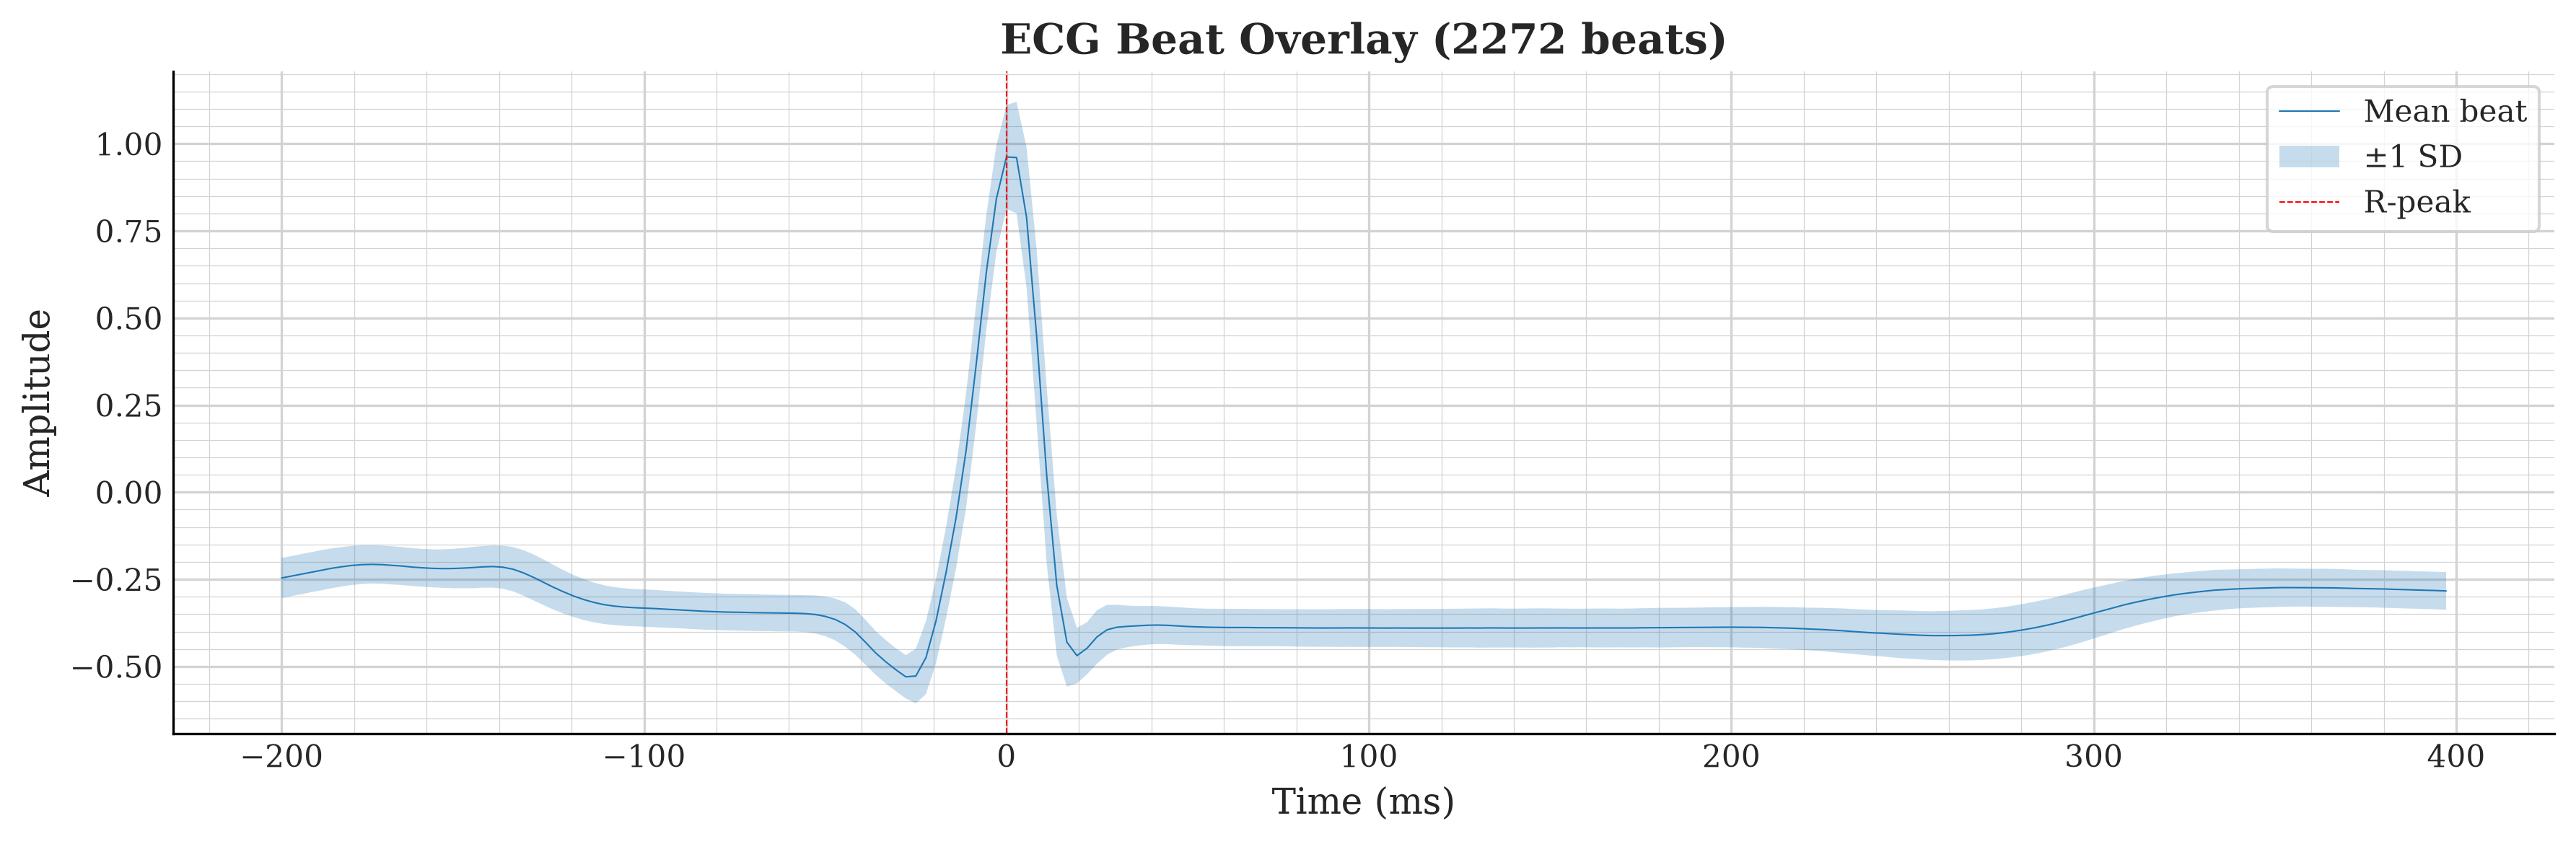

In [9]:
plot_beat_overlays(signal, r_peaks)

In [10]:
pd.DataFrame(ann_label_table)[["symbol", "description"]]

,symbol,description
0,,Not an actual annotation
1,N,Normal beat
2,L,Left bundle branch block beat
3,R,Right bundle branch block beat
4,a,Aberrated atrial premature beat
5,V,Premature ventricular contraction
6,F,Fusion of ventricular and normal beat
7,J,Nodal (junctional) premature beat
8,A,Atrial premature contraction
9,S,Premature or ectopic supraventricular beat


In [11]:
summarize_annotation(signal.annotation, signal.sample_rate)

,Property,Value
0,Number of annotations,2274
1,Number of unique symbols,4
2,Unique annotation symbols,"+, A, N, V"
3,First annotation sample,18
4,Last annotation sample,649991
5,First annotation (s),0.05
6,Last annotation (s),1805.531


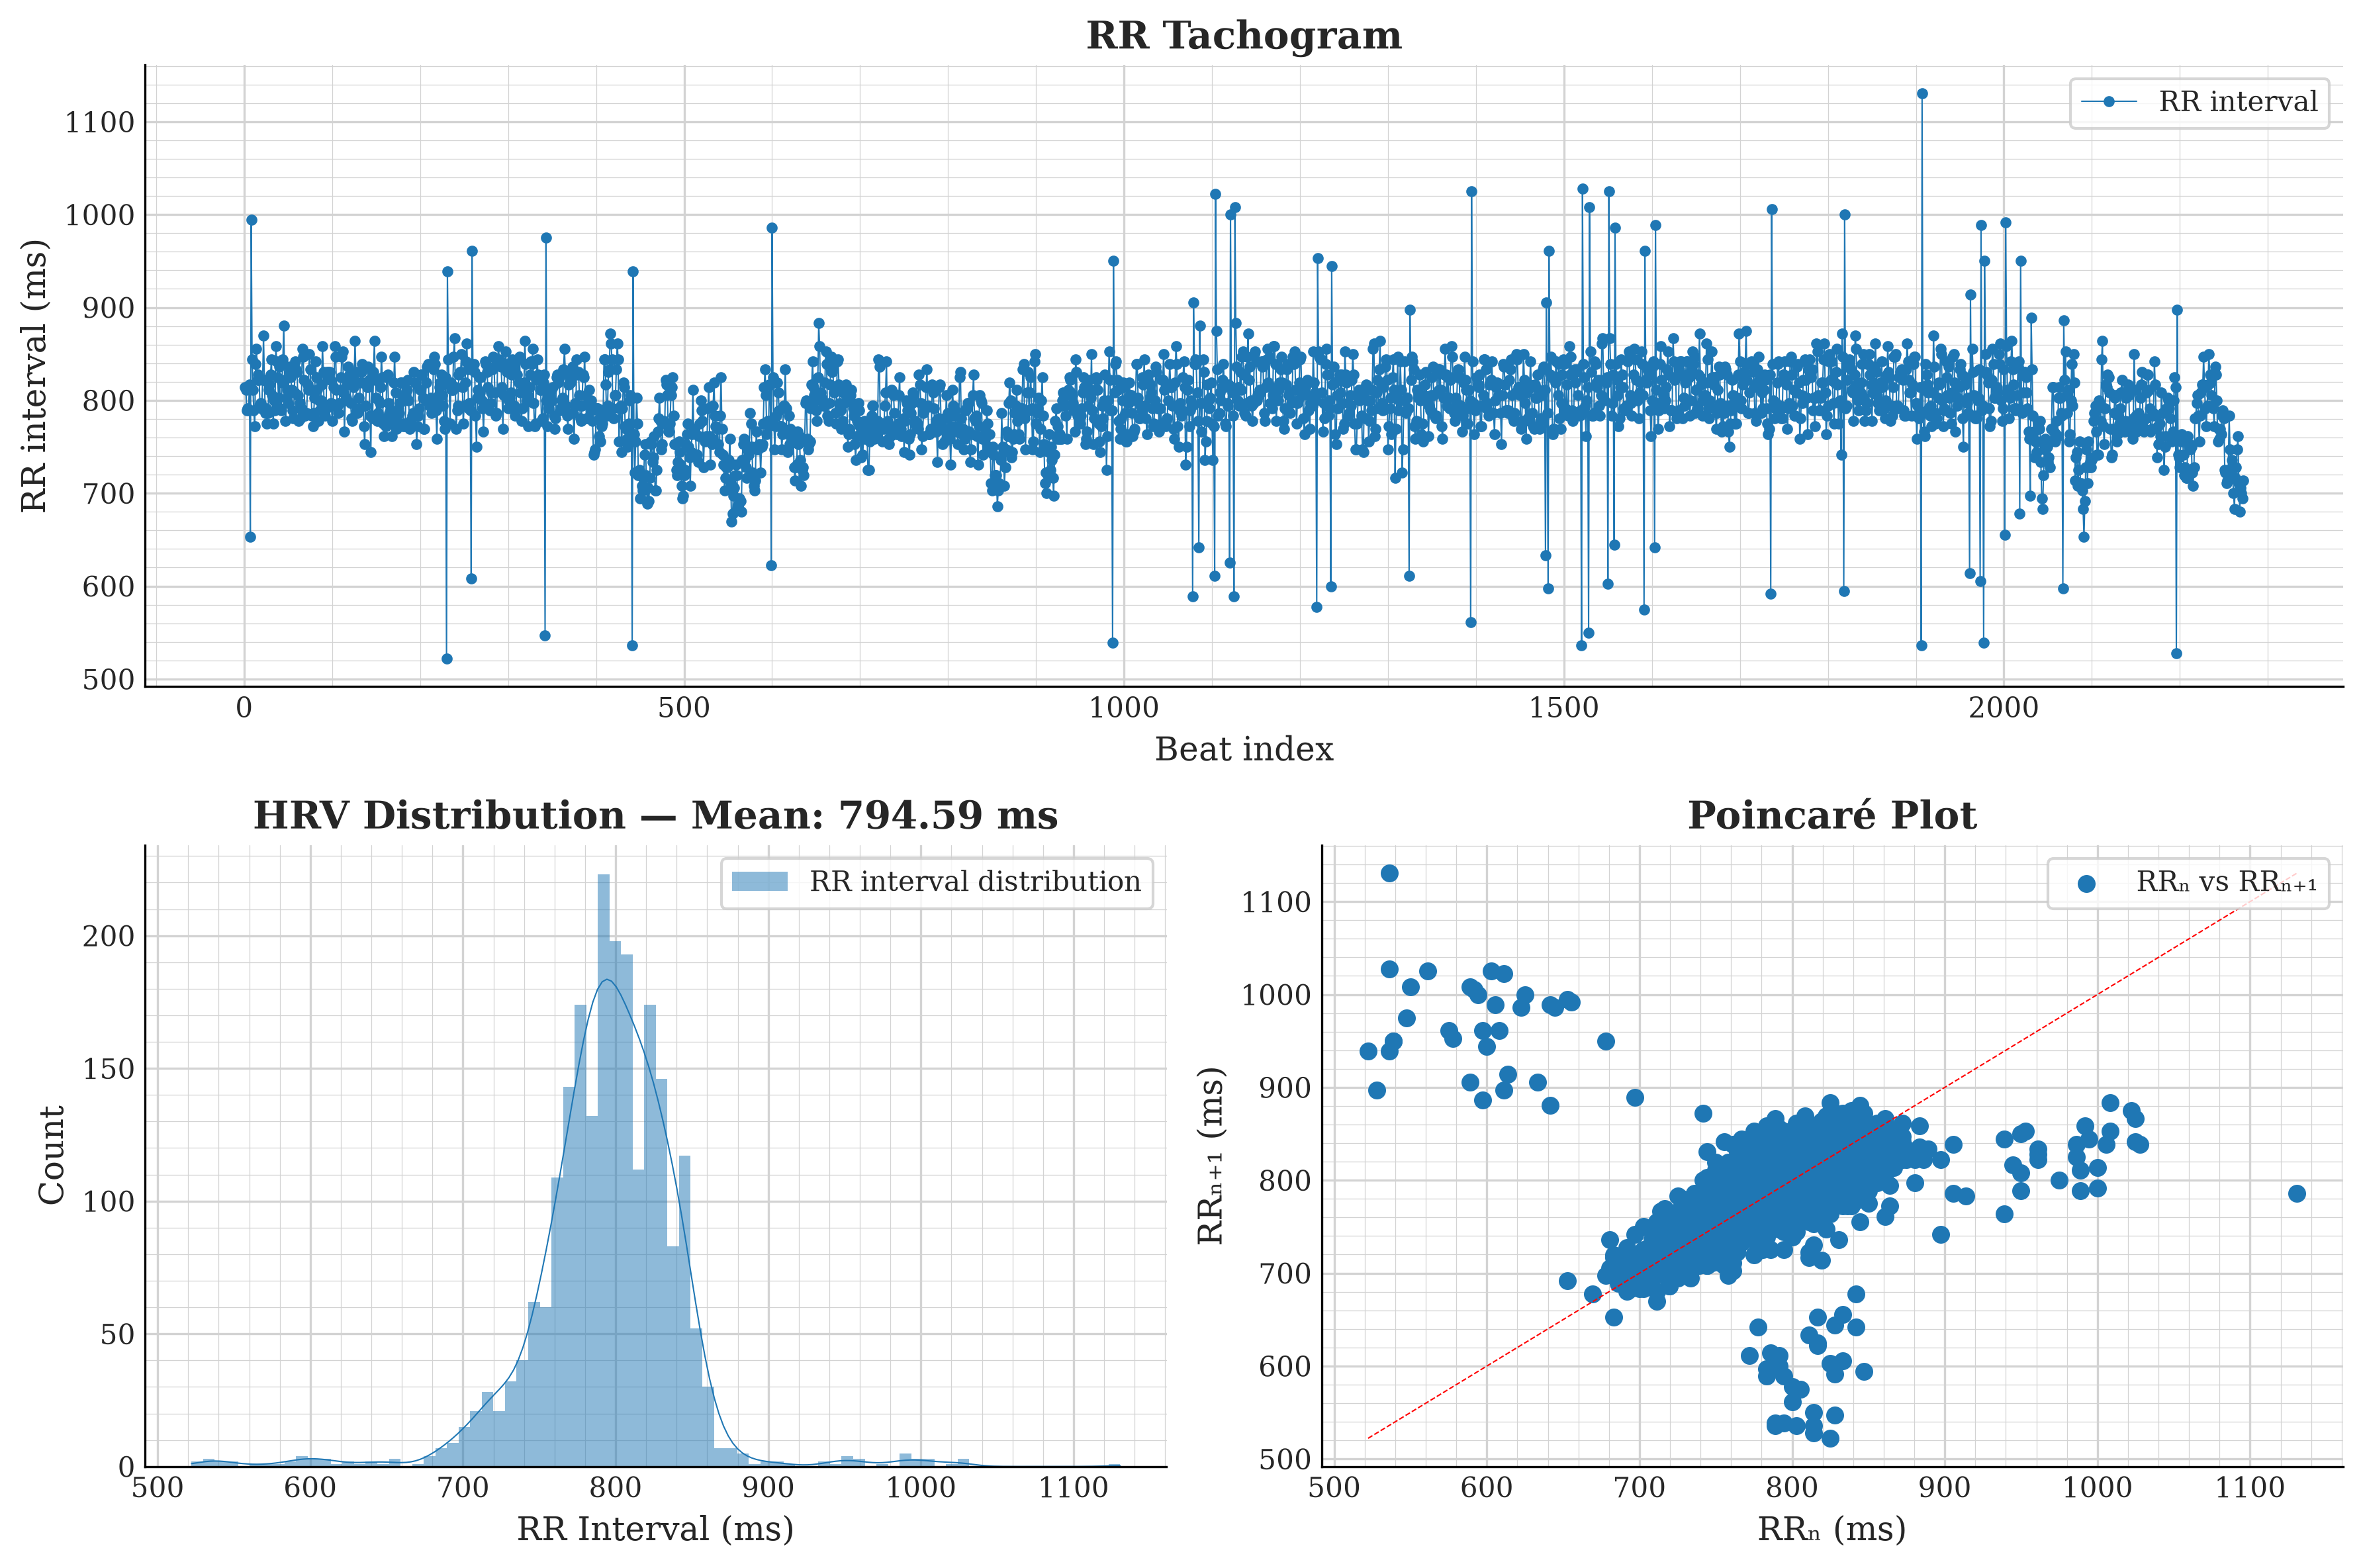

In [12]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
)

ax_top = fig.add_subplot(gs[0, :])

ax_left = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1])

plot_rr_tachogram(signal, r_peaks, ax=ax_top)
plot_rr_distribution(signal, r_peaks, ax=ax_left)
plot_poincare(signal, r_peaks, ax=ax_right)

fig.tight_layout()
plt.show()

In [13]:
summarize_database(MITDB_DIR, get_mitdb_record_names())

,Property,Value
0,Number of records,48
1,Total lead-channels,96
2,Unique lead names,"MLII, V1, V2, V4, V5"
3,Sample rates (Hz),360
4,Total samples,31200000
5,Total duration (s),86666.667
6,Mean duration (s),1805.556
7,Median duration (s),1805.556
8,Mean NaN ratio (%),0.0
9,Mean outlier ratio (%),0.003


In [14]:
summarize_database_annotations(MITDB_DIR, get_mitdb_record_names(), "atr")

,Property,Value
0,Annotation extension,atr
1,Records,48
2,Annotated signals,96
3,Total annotations,225294
4,Mean annotations per signal,2346.812
5,Median annotations per signal,2299.0
6,Minimum annotations per signal,1519
7,Maximum annotations per signal,3400
8,Unique symbols,23
9,Symbols,"!, "", +, /, A, E, F, J, L, N, Q, R, S, V, [, ], a, e, f, j, x, |, ~"
